In [1]:
#importing libraries
# for data manupilation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# for preprocessing and train test split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
#importing data
df=pd.read_csv('earthquake_alert_balanced_dataset.csv')
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [3]:
df['alert'].unique()

array(['green', 'yellow', 'orange', 'red'], dtype=object)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [5]:
#checking null value
df.isnull().sum()

magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

In [6]:
print(" Checking for duplicate rows...")
duplicates = df.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")
if duplicates > 0:
    print("🗑️ Removing duplicates...")
    data = df.drop_duplicates()
    print("Duplicates removed! New dataset shape:", data.shape)
else:
    print("🎉 No duplicates found!")

 Checking for duplicate rows...
Found 44 duplicate rows.
🗑️ Removing duplicates...
Duplicates removed! New dataset shape: (1256, 6)


In [7]:
print("\n🛡️ Detecting and handling outliers...")
numerical_cols=['magnitude', 'depth', 'cdi', 'mmi', 'sig']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"Outliers in {col}: {len(outliers)}")
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
print("Outliers capped using IQR method!")


🛡️ Detecting and handling outliers...
Outliers in magnitude: 13
Outliers in depth: 168
Outliers in cdi: 88
Outliers in mmi: 5
Outliers in sig: 0
Outliers capped using IQR method!


In [8]:
#using label encoder to encode alert
label_enc=LabelEncoder()
df['alert']=label_enc.fit_transform(df['alert'])

In [9]:
df['alert'].unique()

array([0, 3, 1, 2])

Text(0.5, 1.0, 'Correlation matrix')

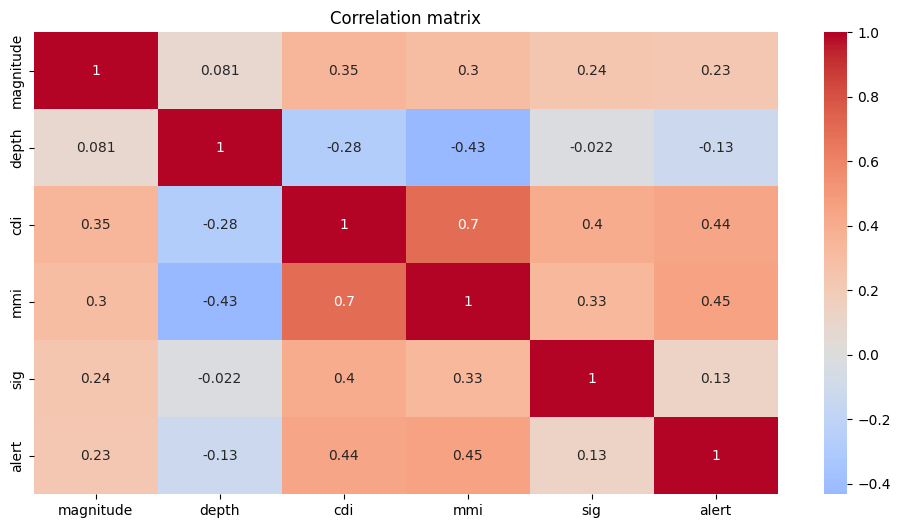

In [10]:
#correlation matrix 
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),
           annot=True,
           center=0,
           cmap='coolwarm')
plt.title("Correlation matrix")

In [11]:
#defing dependent and independent function
X=df.drop('alert',axis=1)
y=df['alert']

In [12]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [13]:
#standardization
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [14]:
#model training
#model training
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,f1_score,roc_auc_score,precision_score

In [15]:
models={
    'logistic regression':LogisticRegression(),
    'SVc':SVC(),
    "knn":KNeighborsClassifier(),
    "naiveB":GaussianNB(),
    'randomforest':RandomForestClassifier(),
    'decision tree':DecisionTreeClassifier(),
    "adaa":AdaBoostClassifier(),
    "GradientBoostingClassifier":GradientBoostingClassifier()
}
for i in range (len(list(models))):
    #model training
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    # model pred
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #prefomance fot training
    model_train_acc=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    #model_train_pre=precision_score(y_train,y_train_pred)
   # model_train_recall=recall_score(y_train,y_train_pred)
    #model_train_roc=roc_auc_score(y_train,y_train_pred)

    #prefomance fot training
    model_test_acc=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
   # model_test_pre=precision_score(y_test,y_test_pred)
    #model_test_recall=recall_score(y_test,y_test_pred)
    #model_test_roc=roc_auc_score(y_test,y_test_pred)

    #print training score
    print("model :",list(models.keys())[i])
    print("preformance on training set")
    print("accuracy :{:.4f}".format(model_train_acc))
    print("f1 Score:{:.4f}".format(model_train_f1))
   # print("precision score :{:.4f}".format(model_train_pre))
    #print("Recall Score :{:.4f}".format(model_train_recall))
    #print("ROC Score{:.4f}".format(model_train_roc))
    print('--------------------------------------------------------------------')
    #print testing score
    print("preformance on testing set")
    print("accuracy :{:.4f}".format(model_test_acc))
    print("f1 Score:{:.4f}".format(model_test_f1))
  #  print("precision score :{:.4f}".format(model_test_pre))
  #  print("Recall Score :{:.4f}".format(model_test_recall))
   # print("ROC Score{:.4f}".format(model_test_roc))

    print("===========================================================================")
    print("\n")





model : logistic regression
preformance on training set
accuracy :0.6758
f1 Score:0.6718
--------------------------------------------------------------------
preformance on testing set
accuracy :0.6487
f1 Score:0.6434


model : SVc
preformance on training set
accuracy :0.8066
f1 Score:0.8060
--------------------------------------------------------------------
preformance on testing set
accuracy :0.8231
f1 Score:0.8228


model : knn
preformance on training set
accuracy :0.9022
f1 Score:0.9013
--------------------------------------------------------------------
preformance on testing set
accuracy :0.8974
f1 Score:0.8962


model : naiveB
preformance on training set
accuracy :0.6484
f1 Score:0.6426
--------------------------------------------------------------------
preformance on testing set
accuracy :0.6744
f1 Score:0.6695


model : randomforest
preformance on training set
accuracy :1.0000
f1 Score:1.0000
--------------------------------------------------------------------
preformance on

In [16]:

#hyper perameter tuneing
from sklearn.model_selection import RandomizedSearchCV
rf_params={"max_depth":[5,10,15,None,8],
           "max_features": ['sqrt', 'log2', 5, 7, 8],
           "min_samples_split":[2,8,15,20],
           "n_estimators":[100,200,500,1000]}
adaboost_param={
    "n_estimators":[50,60,70,80,90],
    "algorithm":['SAMME','SAMME.R']
}
log_params={'penalty':['l1','l2','elasticney'],
            "C":[100,10,0.1,0.01,1],
            'solver':['newton-cg','saga','sag','liblinear','lbfgs']}
dt_params=params={'criterion':['gini', 'entropy', 'log_loss'],
        'splitter':['best','random'],
        'max_depth':[1,2,3,4,5],
       'max_features':['sqrt','log2','auto'],    
}
sv_param= {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'degree': [2, 3, 4],  # Only used if kernel='poly'
    'coef0': [0.0, 0.5, 1.0],  # For 'poly' and 'sigmoid'
    'class_weight': [None, 'balanced']
}

knn_param = {
    'n_neighbors': list(range(3, 16, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grad_params={'loss':['log_loss', 'exponential','deviance'],
             'criterion':['friedman_mse', 'squared_error','mse'],
             'min_samples_split':[2,8,15,20],
             'n_estimators':[100,200,500,1000],
             'max_depth':[5,8,15,None]

             }


In [17]:
#hyper parameter tuning
from sklearn.model_selection import GridSearchCV,StratifiedKFold
randomcvmodels=[("RF",RandomForestClassifier(),rf_params),("LogisticRegression",LogisticRegression(),log_params),
                ("AdaBoostClassifier",AdaBoostClassifier(),adaboost_param),
               ("DecisionTreeClassifier",DecisionTreeClassifier(),dt_params),
               ("SVC",SVC(),sv_param),
               ("KNN",KNeighborsClassifier(),knn_param),
               ("Grad",GradientBoostingClassifier(),grad_params)]

model_param={}
for name,model,param in randomcvmodels:
    random=RandomizedSearchCV(
        estimator=model,
        param_distributions=param,
        n_iter=100,
        verbose=2,
        cv=3
    )
    random.fit(X_train,y_train)
    model_param[name]=random.best_params_

for modelname in model_param:
    print(f"best parameter for {modelname}  ::")
    print(model_param[modelname])




Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=15, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=15, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=5, max_features=5, min_samples_split=8, n_estimators=200; total time=   0.2s
[CV] END max_depth=5, max_features=5, min_samples_split=8, n_estimators=200; total time=   0.1s
[CV] END max_depth=5, max_features=5, min_samples_split=8, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=7, min_samples_split=20, n_estimators=500; total time=   0.6s
[CV] END max_depth=10, max_features=7, min_samples_split=20, n_estimators=500; total time=   0.5s
[CV] END max_depth=10, max_features=7, min_samples_split=20, n_estimators=500; total time=   0.5s
[CV] END max_depth=10, max_features=8, min_samples_spli

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 75 is smaller than n_iter=100. Running 75 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296

[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.0s
[CV] END .....................C=100, penalty=l1, solver=saga; total time=   0.0s
[CV] END ......................C=100, penalty=l1, solver=sag; total time=   0.0s
[CV] END ......................C=100, penalty=l1, solver=sag; total time=   0.0s
[CV] END ......................C=100, penalty=l1, solver=sag; total time=   0.0s
[CV] END ................C=100, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ................C=100, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ................C=100, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END ....................C=100, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END ....................C=100, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END ....................C=100, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END ................C=100, penalty=l2, solver=newton-cg; total time=   0.0s
[CV] END ................C=1

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is depreca

[CV] END .................C=10, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END .................C=10, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END .................C=10, penalty=l1, solver=liblinear; total time=   0.0s
[CV] END .....................C=10, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END .....................C=10, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END .....................C=10, penalty=l1, solver=lbfgs; total time=   0.0s
[CV] END .................C=10, penalty=l2, solver=newton-cg; total time=   0.0s
[CV] END .................C=10, penalty=l2, solver=newton-cg; total time=   0.0s
[CV] END .................C=10, penalty=l2, solver=newton-cg; total time=   0.0s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=   0.0s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=   0.0s
[CV] END ......................C=10, penalty=l2, solver=saga; total time=   0.0s
[CV] END ...................

...

[CV] END C=100, class_weight=balanced, coef0=1.0, degree=4, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END C=100, class_weight=balanced, coef0=1.0, degree=4, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, coef0=1.0, degree=3, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, coef0=1.0, degree=3, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END C=0.1, class_weight=balanced, coef0=1.0, degree=3, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END C=1, class_weight=balanced, coef0=0.5, degree=3, gamma=auto, kernel=poly; total time=   0.0s
[CV] END C=1, class_weight=balanced, coef0=0.5, degree=3, gamma=auto, kernel=poly; total time=   0.0s
[CV] END C=1, class_weight=balanced, coef0=0.5, degree=3, gamma=auto, kernel=poly; total time=   0.0s
[CV] END C=1, class_weight=None, coef0=0.0, degree=4, gamma=auto, kernel=linear; total time=   0.0s
[CV] END C=1, class_weight=None, coef0=0.0, degree=4, gamma=auto, kern

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 28 is smaller than n_iter=100. Running 28 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ..metric=euclidean, n_neighbors=11, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=11, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=11, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=11, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=11, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=13, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=13, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=13, weights=uniform; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=13, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=13, weights=distance; total time=   0.0s
[CV] END .metric=euclidean, n_neighbors=13, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=15, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean,

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
243 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
93 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Use

best parameter for RF  ::
{'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
best parameter for LogisticRegression  ::
{'solver': 'saga', 'penalty': 'l1', 'C': 1}
best parameter for AdaBoostClassifier  ::
{'n_estimators': 70, 'algorithm': 'SAMME'}
best parameter for DecisionTreeClassifier  ::
{'splitter': 'best', 'max_features': 'log2', 'max_depth': 5, 'criterion': 'entropy'}
best parameter for SVC  ::
{'kernel': 'rbf', 'gamma': 'scale', 'degree': 4, 'coef0': 0.5, 'class_weight': None, 'C': 100}
best parameter for KNN  ::
{'weights': 'distance', 'n_neighbors': 3, 'metric': 'euclidean'}
best parameter for Grad  ::
{'n_estimators': 200, 'min_samples_split': 20, 'max_depth': 15, 'loss': 'log_loss', 'criterion': 'squared_error'}


In [19]:
models={
    'logistic regression':LogisticRegression(solver='saga',penalty='l1',C=1),
    'SVc':SVC(kernel='rbf',gamma='scale',degree=4,coef0=0.5,class_weight=None,C=100),
    "knn":KNeighborsClassifier(weights='distance',n_neighbors=3,metric='euclidean'),
    "naiveB":GaussianNB(),
    'randomforest':RandomForestClassifier(n_estimators =100, min_samples_split= 2,max_features= 'log2',max_depth= None),
    'decision tree':DecisionTreeClassifier(splitter='best',max_features='log2',max_depth=5,criterion='entropy'),
    "adaa":AdaBoostClassifier(n_estimators=70,algorithm='SAMME'),
    "GradientBoostingClassifier":GradientBoostingClassifier(n_estimators=200,min_samples_split=20,max_depth=15,loss='log_loss',criterion='squared_error')
}
for i in range (len(list(models))):
    #model training
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    # model pred
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #prefomance fot training
    model_train_acc=accuracy_score(y_train,y_train_pred)
    model_train_f1=f1_score(y_train,y_train_pred,average='weighted')
    #model_train_pre=precision_score(y_train,y_train_pred)
   # model_train_recall=recall_score(y_train,y_train_pred)
    #model_train_roc=roc_auc_score(y_train,y_train_pred)

    #prefomance fot training
    model_test_acc=accuracy_score(y_test,y_test_pred)
    model_test_f1=f1_score(y_test,y_test_pred,average='weighted')
   # model_test_pre=precision_score(y_test,y_test_pred)
    #model_test_recall=recall_score(y_test,y_test_pred)
    #model_test_roc=roc_auc_score(y_test,y_test_pred)

    #print training score
    print("model :",list(models.keys())[i])
    print("preformance on training set")
    print("accuracy :{:.4f}".format(model_train_acc))
    print("f1 Score:{:.4f}".format(model_train_f1))
   # print("precision score :{:.4f}".format(model_train_pre))
    #print("Recall Score :{:.4f}".format(model_train_recall))
    #print("ROC Score{:.4f}".format(model_train_roc)
    print('--------------------------------------------------------------------')
    #print testing score
    print("preformance on testing set")
    print("accuracy :{:.4f}".format(model_test_acc))
    print("f1 Score:{:.4f}".format(model_test_f1))
  #  print("precision score :{:.4f}".format(model_test_pre))
  #  print("Recall Score :{:.4f}".format(model_test_recall))
   # print("ROC Score{:.4f}".format(model_test_roc))

    print("===========================================================================")
    print("\n")





model : logistic regression
preformance on training set
accuracy :0.6714
f1 Score:0.6675
--------------------------------------------------------------------
preformance on testing set
accuracy :0.6436
f1 Score:0.6385


model : SVc
preformance on training set
accuracy :0.9418
f1 Score:0.9417
--------------------------------------------------------------------
preformance on testing set
accuracy :0.8897
f1 Score:0.8890


model : knn
preformance on training set
accuracy :1.0000
f1 Score:1.0000
--------------------------------------------------------------------
preformance on testing set
accuracy :0.8923
f1 Score:0.8914


model : naiveB
preformance on training set
accuracy :0.6484
f1 Score:0.6426
--------------------------------------------------------------------
preformance on testing set
accuracy :0.6744
f1 Score:0.6695


model : randomforest
preformance on training set
accuracy :1.0000
f1 Score:1.0000
--------------------------------------------------------------------
preformance on

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


model : adaa
preformance on training set
accuracy :0.6484
f1 Score:0.6452
--------------------------------------------------------------------
preformance on testing set
accuracy :0.6256
f1 Score:0.6244


model : GradientBoostingClassifier
preformance on training set
accuracy :1.0000
f1 Score:1.0000
--------------------------------------------------------------------
preformance on testing set
accuracy :0.9103
f1 Score:0.9097


